In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import json

# Load preprocessed documents
with open("D:/heisen/IITM/IITM studies/4th year/sem 8/CS6370/codes/project/template_code_part2/output/stopword_removed_docs.txt", "r") as f:
    processed_docs = json.load(f)

# Convert list of tokens back to strings
doc_texts = [" ".join([word for sentence in doc for word in sentence]) for doc in processed_docs]

# Generate TF-IDF matrix
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(doc_texts).toarray()  # shape: (num_docs, vocab_size)

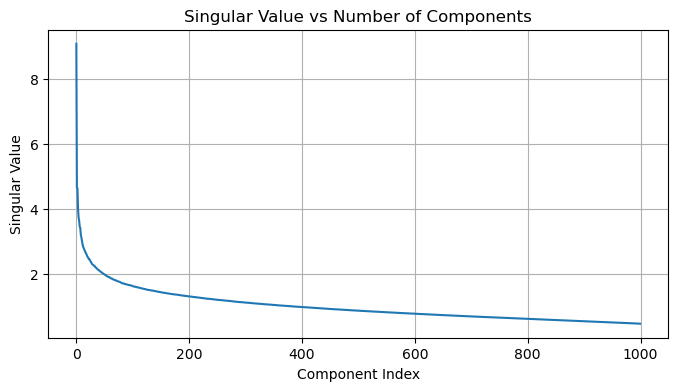

In [2]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Perform SVD
svd = TruncatedSVD(n_components=min(1000, X.shape[1]-1))  # Choose a reasonable upper limit
X_svd = svd.fit_transform(X)

# Plot singular values vs number of components
plt.figure(figsize=(8,4))
plt.plot(svd.singular_values_)
plt.title('Singular Value vs Number of Components')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.grid(True)
plt.savefig("singular_values_plot.png")

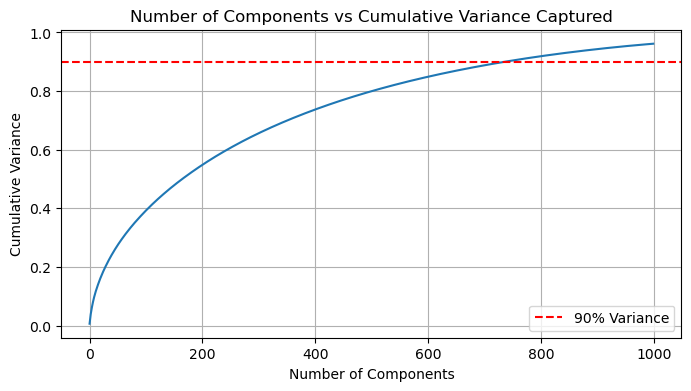

In [3]:
# Explained variance and cumulative variance
explained_variance = svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,4))
plt.plot(cumulative_variance)
plt.title('Number of Components vs Cumulative Variance Captured')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.legend()
plt.savefig("variance_captured_plot.png")

In [4]:
import os
os.chdir("../")

In [5]:
from sentenceSegmentation import SentenceSegmentation
from tokenization import Tokenization
from inflectionReduction import InflectionReduction
from stopwordRemoval import StopwordRemoval
from informationRetrieval import InformationRetrieval
from evaluation import Evaluation
import time
import json
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Setup classes
class SearchEngine:
    def __init__(self, retrieval_mode, segmenter, tokenizer, hidden_dim=100):
        self.segmenter = segmenter
        self.tokenizer_mode = tokenizer
        self.tokenizer = Tokenization()
        self.sentenceSegmenter = SentenceSegmentation()
        self.inflectionReducer = InflectionReduction()
        self.stopwordRemover = StopwordRemoval()
        self.informationRetriever = InformationRetrieval(mode=retrieval_mode, use_wsd=False, hidden_dim=hidden_dim)
        self.evaluator = Evaluation()
        self.dataset_path = 'D:/heisen/IITM/IITM studies/4th year/sem 8/CS6370/codes/project/template_code_part2/cranfield/'
        self.out_folder = ''
    
    def segmentSentences(self, text):
        return self.sentenceSegmenter.naive(text) if self.segmenter == 'naive' else self.sentenceSegmenter.punkt(text)
    
    def tokenize(self, text):
        return self.tokenizer.naive(text) if self.tokenizer_mode == 'naive' else self.tokenizer.pennTreeBank(text)
    
    def reduceInflection(self, text):
        return self.inflectionReducer.reduce(text)
    
    def removeStopwords(self, text):
        return self.stopwordRemover.fromList(text)
    
    def preprocess(self, texts):
        segmented = [self.segmentSentences(t) for t in texts]
        tokenized = [self.tokenize(t) for t in segmented]
        reduced = [self.reduceInflection(t) for t in tokenized]
        stop_removed = [self.removeStopwords(t) for t in reduced]
        return stop_removed
    
    def evaluate(self):
        queries_json = json.load(open(self.dataset_path + 'cran_queries.json', 'r'))
        query_ids = [item['query number'] for item in queries_json]
        queries = [item['query'] for item in queries_json]
        processedQueries = self.preprocess(queries)
        docs_json = json.load(open(self.dataset_path + 'cran_docs.json', 'r'))
        doc_ids = [item['id'] for item in docs_json]
        docs = [item['body'] for item in docs_json]
        processedDocs = self.preprocess(docs)
        self.informationRetriever.buildIndex(processedDocs, doc_ids)
        doc_IDs_ordered = self.informationRetriever.rank(processedQueries)
        qrels = json.load(open(self.dataset_path + 'cran_qrels.json', 'r'))
        results = {"Precision": [], "Recall": [], "F-Score": [], "MAP": [], "nDCG": []}
        for k in range(1, 11):
            results["Precision"].append(self.evaluator.meanPrecision(doc_IDs_ordered, query_ids, qrels, k))
            results["Recall"].append(self.evaluator.meanRecall(doc_IDs_ordered, query_ids, qrels, k))
            results["F-Score"].append(self.evaluator.meanFscore(doc_IDs_ordered, query_ids, qrels, k))
            results["MAP"].append(self.evaluator.meanAveragePrecision(doc_IDs_ordered, query_ids, qrels, k))
            results["nDCG"].append(self.evaluator.meanNDCG(doc_IDs_ordered, query_ids, qrels, k))
        return results

In [7]:
# Run evaluation over different hidden dimensions
dimensions = [50, 100, 200, 400, 800, 1600]
results_by_dim = {}
for dim in dimensions:
    print(f'Evaluating for dimension: {dim}')
    engine = SearchEngine(retrieval_mode='autoencoder', segmenter='punkt', tokenizer='ptb', hidden_dim=dim)
    results = engine.evaluate()
    results_by_dim[dim] = results

Evaluating for dimension: 50
Evaluating for dimension: 100
Evaluating for dimension: 200
Evaluating for dimension: 400
Evaluating for dimension: 800
Evaluating for dimension: 1600


In [8]:
print(results_by_dim)

{50: {'Precision': [0.27111111111111114, 0.22, 0.21037037037037049, 0.18666666666666668, 0.1768888888888889, 0.16444444444444445, 0.15174603174603157, 0.14666666666666667, 0.13876543209876518, 0.1306666666666668], 'Recall': [0.04283419004265235, 0.07020672549557998, 0.09822547218099327, 0.1124808975834775, 0.13129515123106442, 0.14287674769245523, 0.15306634204871636, 0.1706856217293996, 0.17781344841862987, 0.18598276058794203], 'F-Score': [0.07161895828122009, 0.10036439901950436, 0.12555684953036828, 0.13102316266111078, 0.14004389485469032, 0.141674106222492, 0.14130472875754702, 0.14641277342433842, 0.14465432731506972, 0.14261455523635602], 'MAP': [0.04283419004265235, 0.06259504458389904, 0.07805845360286363, 0.08509455929093011, 0.09314283570587316, 0.09753567381113315, 0.10119641959092651, 0.10694816005319328, 0.10921199945543428, 0.11129401003744487], 'nDCG': [0.27111111111111114, 0.2315661574826914, 0.22288066358274516, 0.20995709482653047, 0.20603683259431693, 0.20197606670

In [9]:
engine = SearchEngine(retrieval_mode='tfidf', segmenter='punkt', tokenizer='ptb', hidden_dim=dim)
results = engine.evaluate()
print(results)

{'Precision': [0.6933333333333334, 0.5622222222222222, 0.5214814814814818, 0.45555555555555555, 0.410666666666667, 0.3792592592592593, 0.3568253968253971, 0.33611111111111114, 0.3145679012345682, 0.29244444444444456], 'Recall': [0.11906330233721418, 0.18423050331754293, 0.24663239422667918, 0.28110948380376866, 0.31113801654076395, 0.3398215768564405, 0.3666374030056, 0.3938235522852692, 0.41035691218407866, 0.4234653777925443], 'F-Score': [0.19487521110610034, 0.2603912814934069, 0.31152404916091997, 0.32224535573476687, 0.32734207732046844, 0.3309079498933538, 0.3342732267905276, 0.3354637938423844, 0.32968484971790196, 0.32044489882658606], 'MAP': [0.11906330233721418, 0.176794240100578, 0.2245527060811157, 0.24798255308596254, 0.26477996404178417, 0.28037861100955447, 0.2943934841434752, 0.30719828410566713, 0.3144707934573216, 0.31885915324568126], 'nDCG': [0.6933333333333334, 0.5918919305473866, 0.559213192553799, 0.5223787949442965, 0.5008883554107574, 0.49103083072324183, 0.487

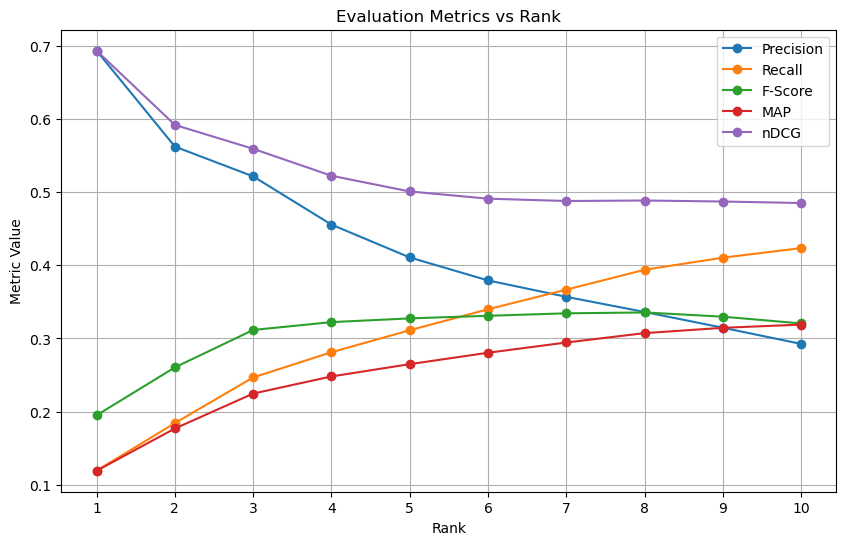

In [10]:
import matplotlib.pyplot as plt

ranks = list(range(1, 11))

plt.figure(figsize=(10, 6))
for metric, values in results.items():
    plt.plot(ranks, values, marker='o', label=metric)
plt.title('Evaluation Metrics vs Rank')
plt.xlabel('Rank')
plt.ylabel('Metric Value')
plt.xticks(ranks)
plt.legend()
plt.grid(True)
plt.savefig("D:/heisen/IITM/IITM studies/4th year/sem 8/CS6370/codes/project/template_code_part2/ablation study/base model ir")
plt.show()


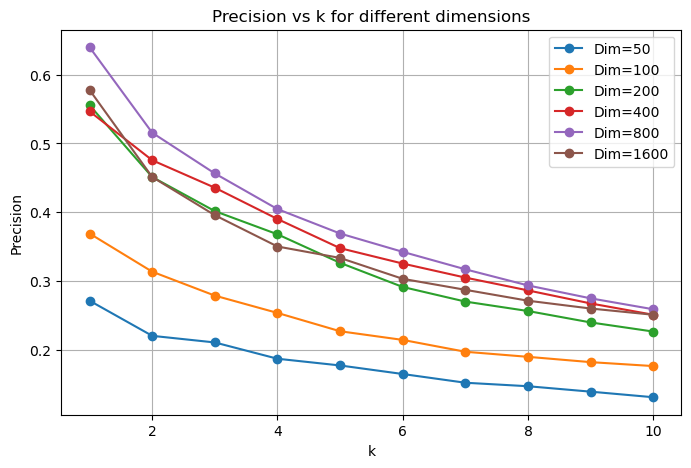

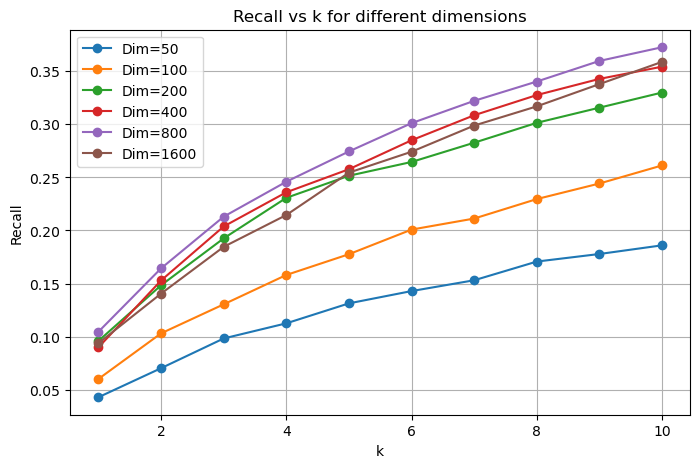

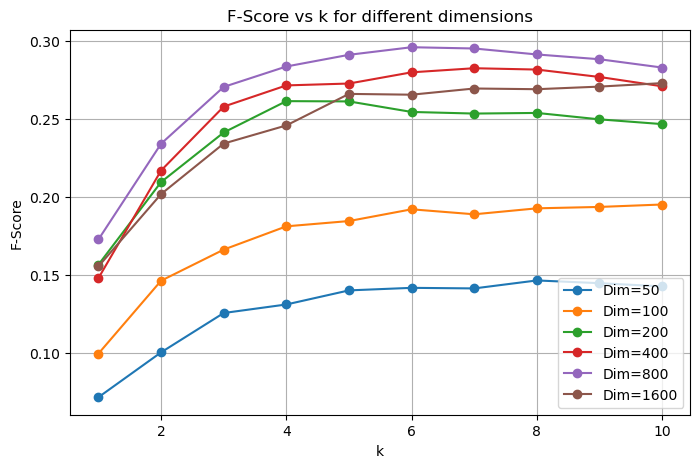

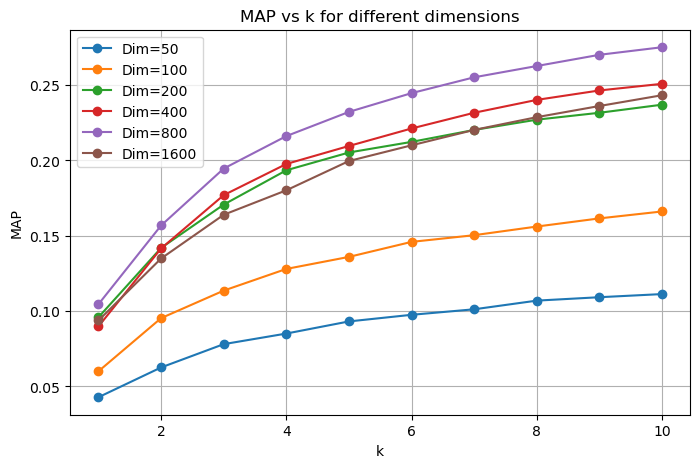

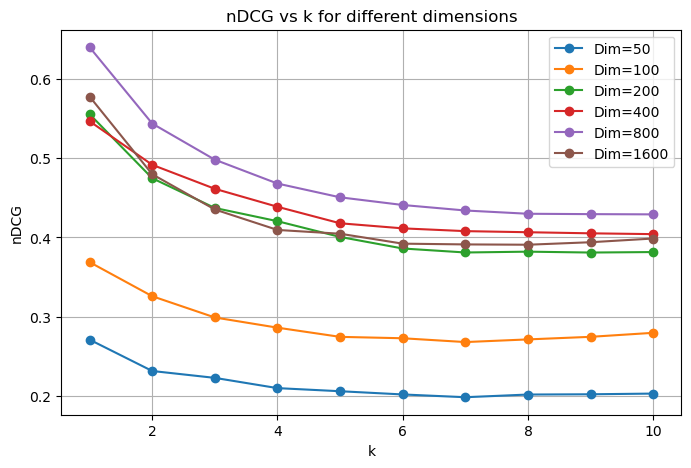

In [11]:
# Plot the results
metrics = ['Precision', 'Recall', 'F-Score', 'MAP', 'nDCG']
for metric in metrics:
    plt.figure(figsize=(8, 5))
    for dim in dimensions:
        plt.plot(range(1, 11), results_by_dim[dim][metric], label=f'Dim={dim}', marker='o')
    plt.title(f'{metric} vs k for different dimensions')
    plt.xlabel('k')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.savefig(f'D:/heisen/IITM/IITM studies/4th year/sem 8/CS6370/codes/project/template_code_part2/ablation study/{metric} Autoencoder score vs K for different dimensions')